<a href="https://colab.research.google.com/github/Javier0CG/soduku_resolver/blob/main/actividad_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

version de Tensorflow 2.19.0
version de Keras 3.13.2
version de Numpy 2.0.2
version de Pandas 2.2.2
version de Matplotlib 3.10.0


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,713 (77.00 KB)

 Trainable params: 19,713 (77.00 KB)

 Non-trainable params: 0 (0.00 B)

None
      Fe     C     Cr     Ni    Mn     S    Si    Mo     V     W    Co    Al  \
0  55.79  0.46  17.11  14.64  1.20  0.01  0.31  0.29  0.87  3.01  3.54  0.02   
1  70.57  0.37   9.45   8.64  0.58  0.03  0.28  1.46  0.37  2.28  3.93  0.20   
2  82.93  0.73   3.07   1.30  1.90  0.05  1.62  1.52  0.10  3.42  2.20  0.12   
3  63.60  0.38   9.36  10.93  0.37  0.05  1.55  4.70  0.89  2.99  4.61  0.09   
4  67.83  0.47   4.88  16.57  0.71  0.01  1.09  0.70  0.80  0.37  4.93  0.77   

      P    Cu    Ti  Tensile_Strength_MPa  
0  0.05  2.50  0.21               1186.48  
1  0.03  1.78  0.05                911.92  
2  0.02  0.10  0.91               1154.17  
3  0.01  0.14  0.33               1125.14  
4  0.01  0.02  0.82               1058.12  
datos cargados
(15, 5555)
(5555, 15)
(5555,)
datos de entrada listos datos de entrada listos datos de entrada listos datos de entrada listos datos de entrada listos datos de entrada listos datos de entrada listos datos de entrada listos datos de entr

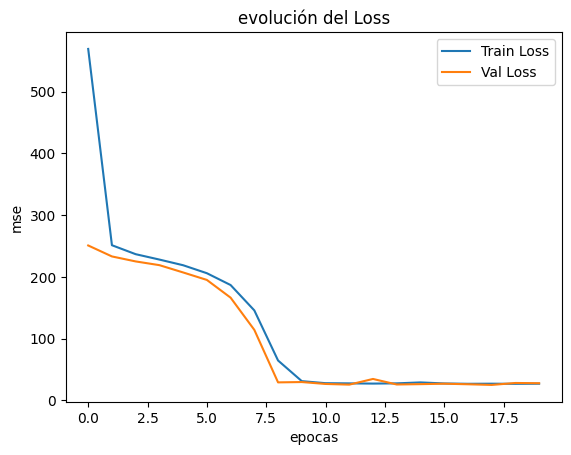

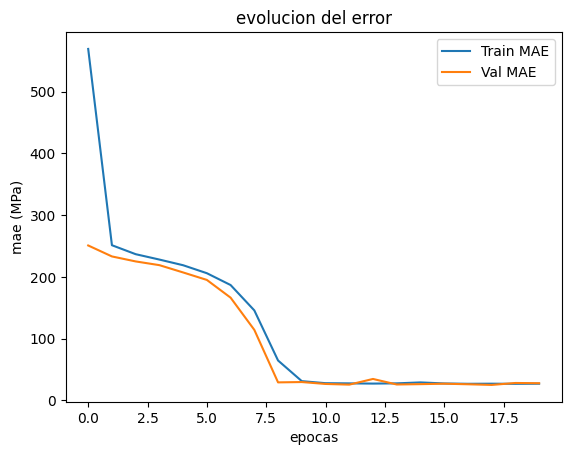

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Predicciones:
x = 55.7 -> y_pred = 1210.2615966796875


In [2]:
import tensorflow as tf
import keras
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print("version de Tensorflow",tf.__version__)
print("version de Keras", keras.__version__)
print("version de Numpy", np.__version__)
print("version de Pandas", pd.__version__)
print("version de Matplotlib", matplotlib.__version__)



# units=1               numero de neuronas
# entradas              input_shape=[1]
# activation="linear"   activacion (linear, relu, sigmoid, softmax, etc)

red_neuronal_steels = tf.keras.Sequential([
      tf.keras.layers.Dense(units=64, activation="relu", input_shape=[15]),
      tf.keras.layers.Dense(units=128, activation="relu"),
      tf.keras.layers.Dense(units=64, activation="relu"),
      tf.keras.layers.Dense(units=32, activation="relu"),
      tf.keras.layers.Dense(units=1)
                                          ])

print(red_neuronal_steels.summary())


#optimizers: Adadelta, Adafactor, Adagrad, Adam, AdamW, Adamax, Ftrl, Lion, LossScaleOptimizer, Nadam, Optimizer, RMSprop, SGD
#loss: BinaryCrossentropy, BinaryFocalCrossentropy, CTC, CategoricalCrossentropy, CategoricalFocalCrossentropy, CategoricalHinge, CosineSimilarity, Dice, Hinge, Huber, KLDivergence, LogCosh, Loss, MeanAbsoluteError, MeanAbsolutePercentageError, MeanSquaredError, MeanSquaredLogarithmicError, Poisson, SparseCategoricalCrossentropy, SquaredHinge, Tversky
#metrics: Accuracy, BinaryAccuracy, CategoricalAccuracy, SparseCategoricalAccuracy, TopKCategoricalAccuracy, SparseTopKCategoricalAccuracy, Mean, Sum, MeanAbsoluteError, MeanSquaredError, RootMeanSquaredError, MeanAbsolutePercentageError, MeanSquaredLogarithmicError, CosineSimilarity, LogCoshError, KLDivergence, Poisson, Precision, Recall, AUC, BinaryCrossentropy, CategoricalCrossentropy, SparseCategoricalCrossentropy

red_neuronal_steels.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001),
    loss="mae",
    metrics=["mae"]
                            )

#datos
df = pd.read_csv("/content/steel_compositions_db.csv")
print(df.head())

datos_fe = df["Fe"]
datos_c = df["C"]
datos_cr = df["Cr"]
datos_ni = df["Ni"]
datos_mn = df["Mn"]
datos_s = df["S"]
datos_si = df["Si"]
datos_mo = df["Mo"]
datos_v = df["V"]
datos_w = df["W"]
datos_co = df["Co"]
datos_al = df["Al"]
datos_p = df["P"]
datos_cu = df["Cu"]
datos_ti = df["Ti"]
datos_ts = df["Tensile_Strength_MPa"]

print("datos cargados")

datos_entrada = np.stack((datos_fe, datos_c, datos_cr, datos_ni, datos_mn, datos_s, datos_si, datos_mo, datos_v, datos_w, datos_co, datos_al, datos_p, datos_cu, datos_ti))
print(datos_entrada.shape)
datos_entrada = datos_entrada.T
print(datos_entrada.shape)
print(datos_ts.shape)

print("datos de entrada listos "*20)

# datos_entrada = df.drop(columns=["Tensile_Strength_MPa"]).values
# datos_ts = df["Tensile_Strength_MPa"].values

# print(datos_entrada.shape)
# print(datos_ts.shape)

entrenamiento_modelo = red_neuronal_steels.fit(
    datos_entrada,
    datos_ts,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
                                              )

# perdida (loss)
plt.figure()
plt.plot(entrenamiento_modelo.history['loss'], label='Train Loss')
plt.plot(entrenamiento_modelo.history['val_loss'], label='Val Loss')
plt.xlabel('epocas')
plt.ylabel('mse')
plt.title('evolución del Loss')
plt.legend()
plt.show()


# MAE error absoluto medio
plt.figure()
plt.plot(entrenamiento_modelo.history['mae'], label='Train MAE')
plt.plot(entrenamiento_modelo.history['val_mae'], label='Val MAE')
plt.xlabel('epocas')
plt.ylabel('mae (MPa)')
plt.title('evolucion del error')
plt.legend()
plt.show()


X_test = np.array([[55.7,0.46,17.11,14.64,1.2,0.01,0.31,0.29,0.87,3.01,3.54,.02,0.05,2.5,0.21]], dtype=float)
predictions = red_neuronal_steels.predict(X_test)

print("Predicciones:")
for i, val in enumerate(X_test):
    print(f"x = {val[0]} -> y_pred = {predictions[i][0]}")





In [3]:
X_test = np.array([[55.7,0.10,17.11,14.64,1.2,0.05,0.31,0.29,0.87,3.01,3.54,.02,0.05,2.5,0.21]], dtype=float)
prediccion_lc = red_neuronal_steels.predict(X_test)
print("predicción bajando el carbono y subiendo el azufre", prediccion_lc, "MPa")

X_test = np.array([[55.7,0.85,17.11,14.64,1.2,0.01,0.31,0.29,0.87,3.01,3.54,.02,0.05,2.5,0.21]], dtype=float)
prediccion_hc = red_neuronal_steels.predict(X_test)
print("predicción subiendo el carbono", prediccion_hc, "MPa")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
predicción bajando el carbono y subiendo el azufre [[912.95886]] MPa
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
predicción subiendo el carbono [[1523.7976]] MPa
